sparse depth estimation
- image rectification for stereo image pair
- detect key feature points (e.g., using SIFT)
- match features between left and right images
- compute disparity at matched keypoints
- estimate depth for these sparse points

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

load stereo images

In [2]:
imgL_col = cv2.imread("images/left_image.jpg")
imgL = cv2.cvtColor(imgL_col, cv2.COLOR_BGR2GRAY)
imgL_col = cv2.cvtColor(imgL_col, cv2.COLOR_BGR2RGB)

imgR_col = cv2.imread("images/right_image.jpg")
imgR = cv2.cvtColor(imgR_col, cv2.COLOR_BGR2GRAY)
imgR_col = cv2.cvtColor(imgR_col, cv2.COLOR_BGR2RGB)

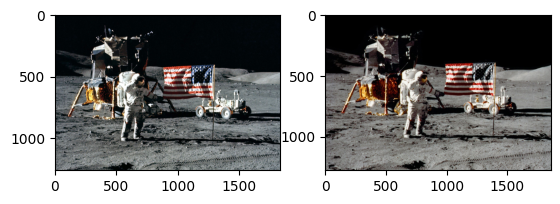

In [3]:
plt.subplot(121)
plt.imshow(imgL_col)
plt.subplot(122)
plt.imshow(imgR_col)

In [4]:
# camera parameters (just default values here)
K1 = np.array([[800, 0, 640], [0, 800, 360], [0, 0, 1]])  # intrinsic matrix for left camera
K2 = np.array([[800, 0, 640], [0, 800, 360], [0, 0, 1]])  # intrinsic matrix for right camera
D1 = np.zeros(5)  # distortion coefficients for left camera
D2 = np.zeros(5)  # distortion coefficients for right camera
R = np.eye(3)  # rotation matrix (from stereo calibration)
T = np.array([[0.1, 0, 0]]).T  # translation vector (10 cm baseline)

# compute rectification transforms
image_size = (imgL.shape[1], imgL.shape[0])
R1, R2, P1, P2, Q, _, _ = cv2.stereoRectify(K1, D1, K2, D2, image_size, R, T)

# compute rectification maps
map1L, map2L = cv2.initUndistortRectifyMap(K1, D1, R1, P1, image_size, cv2.CV_16SC2)
map1R, map2R = cv2.initUndistortRectifyMap(K2, D2, R2, P2, image_size, cv2.CV_16SC2)

# apply rectification
imgL_rect = cv2.remap(imgL, map1L, map2L, cv2.INTER_LINEAR)
imgR_rect = cv2.remap(imgR, map1R, map2R, cv2.INTER_LINEAR)

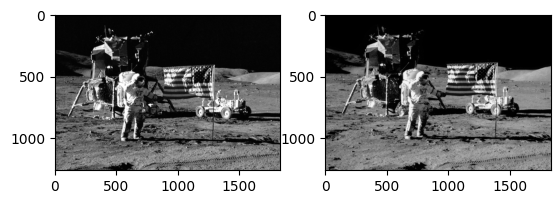

In [5]:
plt.subplot(121)
plt.imshow(imgL_rect, cmap='gray', vmin=0, vmax=255)
plt.subplot(122)
plt.imshow(imgR_rect, cmap='gray', vmin=0, vmax=255)

In [6]:
sift = cv2.SIFT_create()
keypoints1, descriptors1 = sift.detectAndCompute(imgL_rect, None)
keypoints2, descriptors2 = sift.detectAndCompute(imgR_rect, None)
bf = cv2.BFMatcher(cv2.NORM_L2)
matches = bf.match(descriptors1, descriptors2)
matches = sorted(matches, key = lambda x:x.distance)
matches = matches[:50]

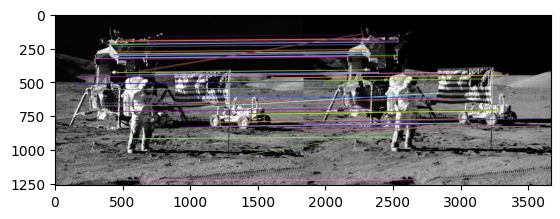

In [7]:
image_matched = cv2.drawMatches(imgL_rect, keypoints1, imgR_rect, keypoints2, matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS, matchesThickness=3)
plt.imshow(image_matched, cmap='gray', vmin=0, vmax=255)

extract point coordinates

In [8]:
left_points = np.float32([keypoints1[m.queryIdx].pt for m in matches])
right_points = np.float32([keypoints2[m.trainIdx].pt for m in matches])

compute disparities (difference in x-coordinates)

In [9]:
disparities = right_points[:, 0] - left_points[:, 0]
disparities

array([-7.9199219e-01,  2.5329254e+01,  1.1353516e+01, -2.2575684e+01,
       -1.9346832e+01, -2.2575684e+01, -8.1531982e+00,  2.7947266e+01,
        2.5828857e+01,  1.0496936e+02,  2.5992554e+01,  2.5290253e+01,
        1.5887573e+01, -1.9346832e+01,  2.7396423e+01,  1.0293640e+02,
        2.1098267e+01, -1.8885986e+02,  1.9198499e+02,  3.1407593e+01,
        2.8171234e+01, -4.7438232e+01,  2.9192596e+01,  5.8829468e+01,
        2.5500275e+01,  2.4165894e+01, -5.4627319e+01, -9.9968018e+01,
        2.3939117e+01,  1.1465759e+01,  2.4337067e+01, -7.9490552e+02,
        1.0882587e+02,  2.4165894e+01, -4.7164355e+02, -7.9199219e-01,
        1.1807074e+02, -6.9869385e+00,  2.4371307e+01,  1.0675232e+01,
       -7.2863770e-01, -6.3964233e+00,  1.8779456e+02,  1.5960693e+01,
       -1.0061841e+02,  2.4911926e+01, -1.3748688e+01,  1.3862366e+01,
       -1.8251044e+02,  2.3333649e+01], dtype=float32)

In [10]:
y_deviations = np.abs(right_points[:, 1] - left_points[:, 1])
y_deviations

array([ 25.926453  ,  16.517471  ,  15.582611  ,  28.92804   ,
        19.265686  ,  28.92804   ,  25.921509  ,  21.07367   ,
        18.35205   ,  21.85147   ,  16.515427  ,  16.918335  ,
        18.052185  ,  19.265686  ,  22.232422  ,  26.71283   ,
        19.70868   , 282.04022   ,   0.51538086,  17.101929  ,
        21.666382  ,  28.522888  ,  20.940369  ,  25.992615  ,
        17.929443  ,  19.137665  , 106.243774  ,  20.219818  ,
        17.782959  ,  15.940231  ,  16.485168  ,   0.74713135,
        26.79187   ,  19.137665  , 219.24335   ,  25.926453  ,
        14.543396  ,  25.590942  ,  15.883835  ,  13.546967  ,
        26.105713  ,  14.325195  ,   2.1031494 ,  18.019562  ,
        19.573578  ,  16.933868  ,  20.965576  ,  24.092651  ,
       274.54376   ,  18.29715   ], dtype=float32)

In [11]:
y_deviations.mean()

np.float32(35.37286)

In [12]:
mask = (y_deviations < 30) & (disparities > 0)
left_points = left_points[mask]
disparities = disparities[mask]

In [13]:
disparities

array([ 25.329254,  11.353516,  27.947266,  25.828857, 104.96936 ,
        25.992554,  25.290253,  15.887573,  27.396423, 102.9364  ,
        21.098267, 191.98499 ,  31.407593,  28.171234,  29.192596,
        58.829468,  25.500275,  24.165894,  23.939117,  11.465759,
        24.337067, 108.82587 ,  24.165894, 118.07074 ,  24.371307,
        10.675232, 187.79456 ,  15.960693,  24.911926,  13.862366,
        23.333649], dtype=float32)

In [14]:
disparities.mean()

np.float32(45.64503)

camera parameters (just guesses here)

In [15]:
focal_length = 800  # in pixels
baseline = 0.1  # in meters

In [16]:
depths = (focal_length * baseline) / disparities

visualize sparse depth points

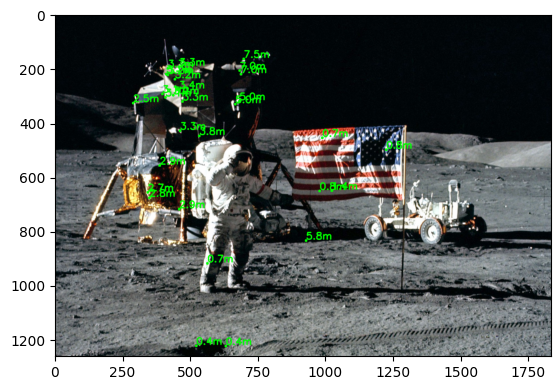

In [17]:
for i in range(len(disparities)):
    x, y = map(int, left_points[i])
    depth = depths[i]
    cv2.circle(imgL_col, (x, y), 5, (0, 255, 0), -1)
    cv2.putText(imgL_col, f"{depth:.1f}m", (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)

plt.imshow(imgL_col, cmap='gray', vmin=0, vmax=255)